In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [17]:
df = pd.read_csv("student_marks_dataset.csv")

In [18]:
df

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Final_Marks
0,101,2,70,60,58,55
1,102,3,75,65,62,60
2,103,4,80,70,68,66
3,104,5,85,75,72,73
4,105,6,88,78,75,77
5,106,7,90,82,80,84
6,107,8,92,85,84,89
7,108,9,94,88,88,93
8,109,10,96,92,91,97
9,110,5,82,73,70,72


In [19]:
df.head()

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Final_Marks
0,101,2,70,60,58,55
1,102,3,75,65,62,60
2,103,4,80,70,68,66
3,104,5,85,75,72,73
4,105,6,88,78,75,77


In [20]:
df.tail()

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Final_Marks
10,111,4,78,68,65,64
11,112,6,86,80,78,81
12,113,3,72,62,60,58
13,114,7,91,84,82,86
14,115,8,95,90,89,94


In [21]:
df.shape

(15, 6)

In [22]:
df.columns

Index(['Student_ID', 'Study_Hours', 'Attendance', 'Assignments',
       'Previous_Marks', 'Final_Marks'],
      dtype='str')

In [23]:
df.info

<bound method DataFrame.info of     Student_ID  Study_Hours  Attendance  Assignments  Previous_Marks  \
0          101            2          70           60              58   
1          102            3          75           65              62   
2          103            4          80           70              68   
3          104            5          85           75              72   
4          105            6          88           78              75   
5          106            7          90           82              80   
6          107            8          92           85              84   
7          108            9          94           88              88   
8          109           10          96           92              91   
9          110            5          82           73              70   
10         111            4          78           68              65   
11         112            6          86           80              78   
12         113            3     

In [10]:
df.describe()

,Student_ID,Study_Hours,Attendance,Marks
count,15.000000,13.000000,14.000000,14.000000
mean,108.000000,4.615385,83.285714,76.285714
std,4.472136,1.850156,12.073038,14.932817
min,101.000000,2.000000,60.000000,50.000000
25%,104.500000,3.000000,76.250000,68.500000
50%,108.000000,5.000000,86.000000,76.500000
75%,111.500000,6.000000,91.500000,88.000000
max,115.000000,8.000000,99.000000,98.000000


In [24]:
df.dtypes

Student_ID        int64
Study_Hours       int64
Attendance        int64
Assignments       int64
Previous_Marks    int64
Final_Marks       int64
dtype: object

In [27]:
df.isnull().sum()

Student_ID        0
Study_Hours       0
Attendance        0
Assignments       0
Previous_Marks    0
Final_Marks       0
dtype: int64

In [28]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Final_Marks', ylabel='Count'>

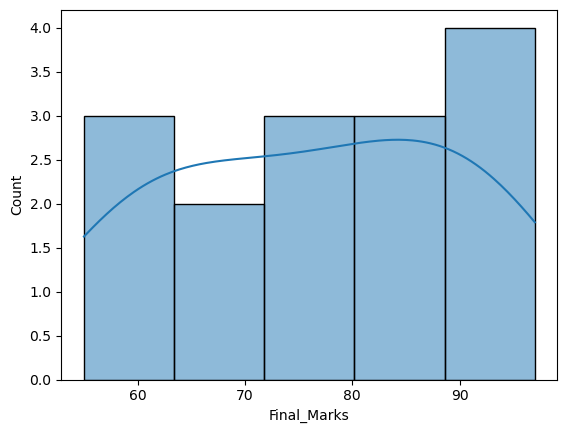

In [29]:
sns.histplot(df["Final_Marks"], kde=True)

<Axes: ylabel='Final_Marks'>

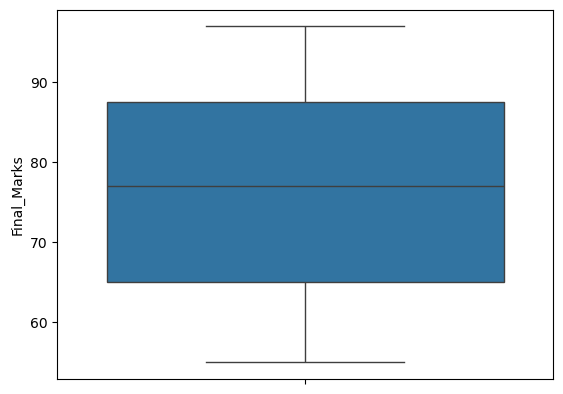

In [30]:
sns.boxplot(y=df["Final_Marks"])

<Axes: xlabel='Study_Hours', ylabel='Final_Marks'>

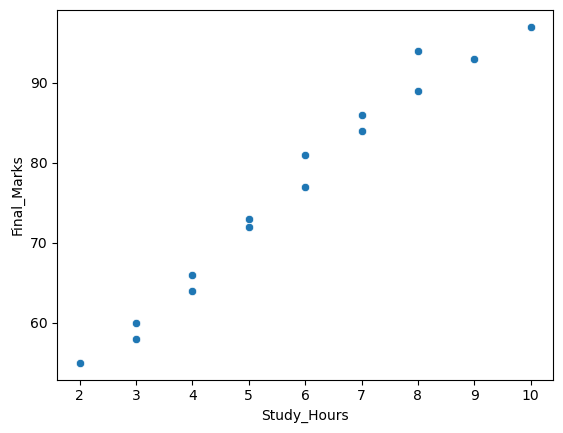

In [31]:
sns.scatterplot(
    x="Study_Hours",
    y="Final_Marks",
    data=df
)

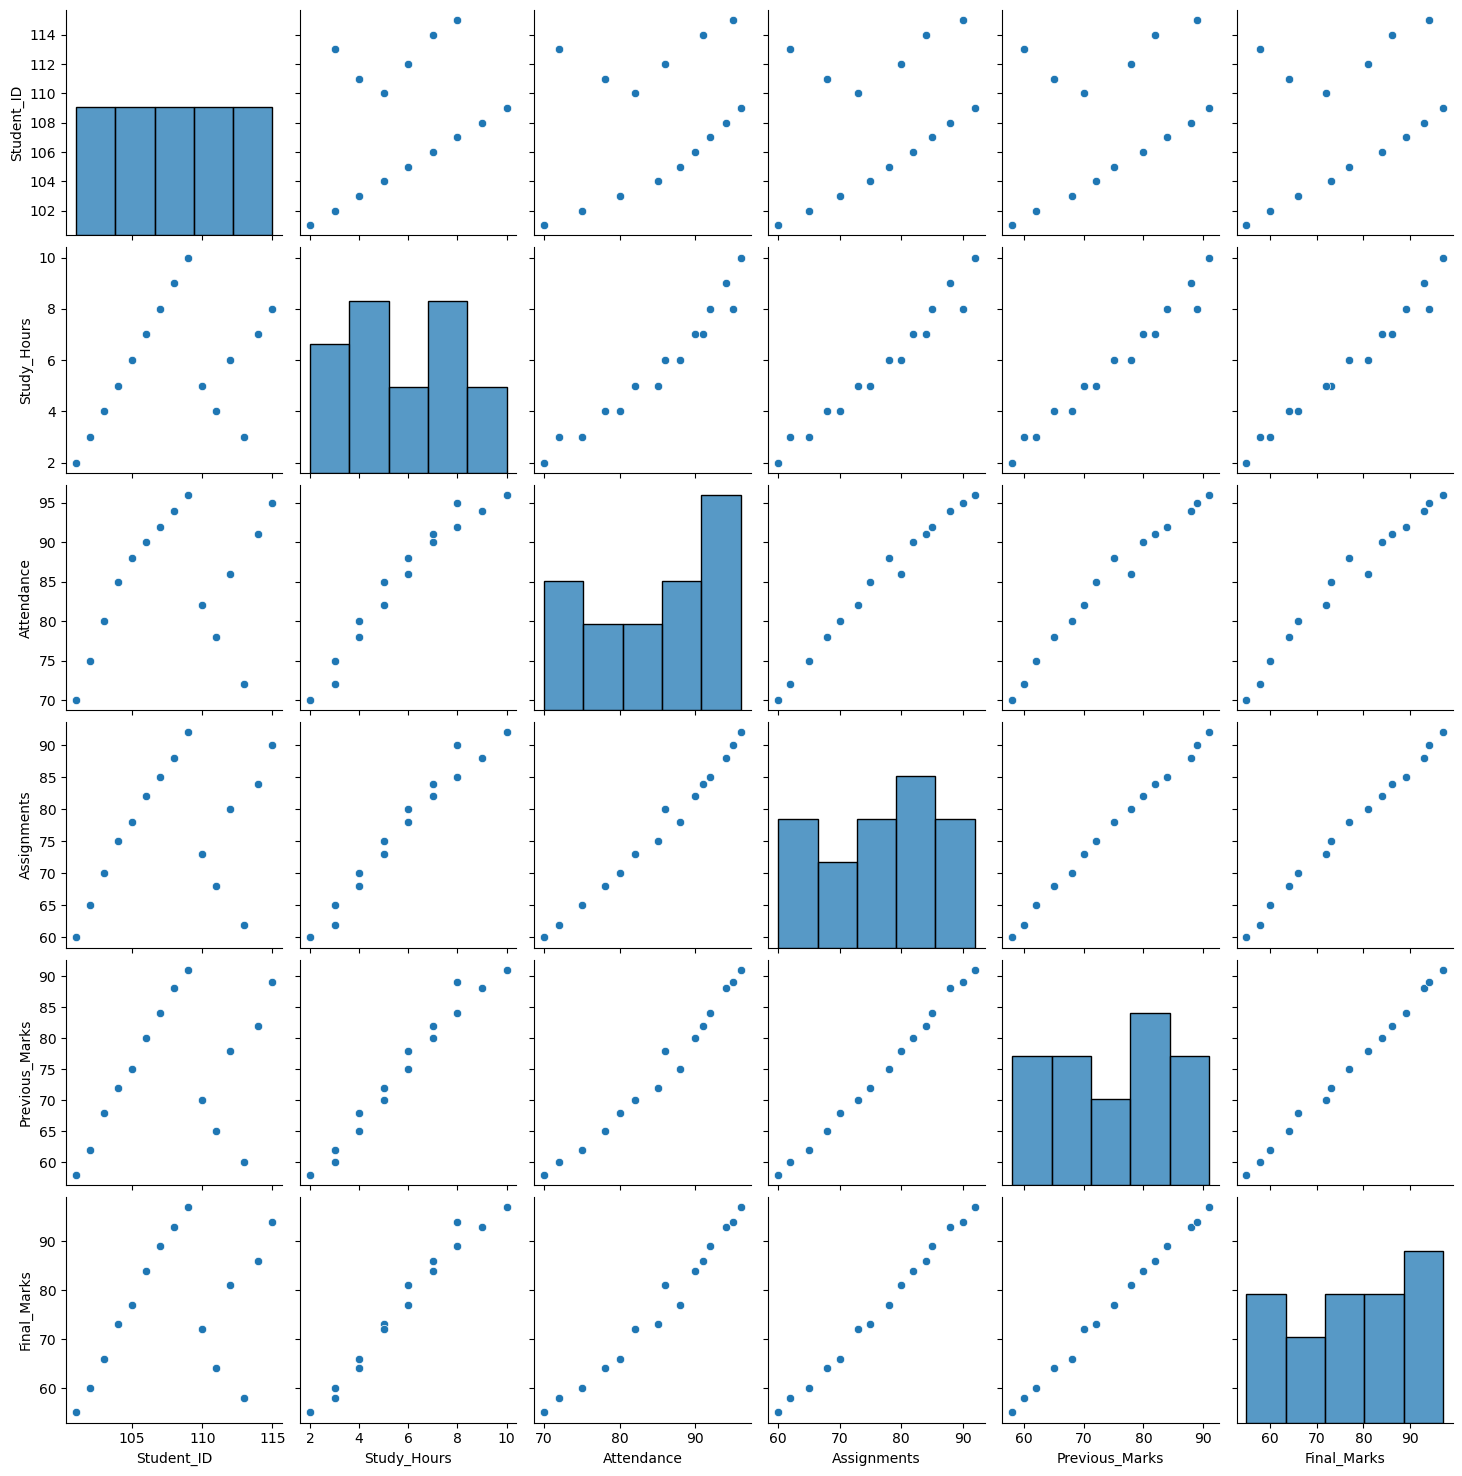

In [32]:
sns.pairplot(df)

<Axes: >

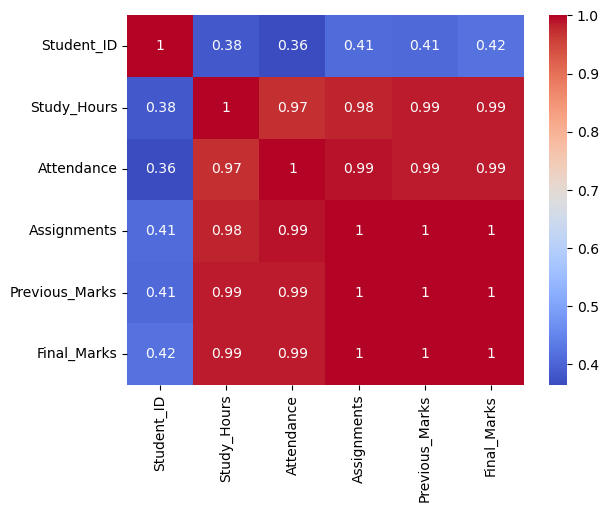

In [33]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

In [34]:
X = df[[
    "Study_Hours",
    "Attendance",
    "Assignments",
    "Previous_Marks"
]]

y = df["Final_Marks"]

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
y_pred = model.predict(X_test)

In [40]:
y_pred

array([70.66590307, 80.15218117, 54.2565326 ])

In [52]:
#mean_absolute_error(y_test, y_pred) calculates the average absolute difference between the actual values (y_test) and the predicted values (y_pred); a lower MAE means better predictions.
mean_absolute_error(y_test, y_pred)

0.9751277212349928

In [53]:
#mean_squared_error(y_test, y_pred) calculates the average of the squared differences between the actual values (y_test) and the predicted values (y_pred); a lower MSE indicates a better model.
mean_squared_error(y_test, y_pred)

1.0171183906138654

In [43]:
#np.sqrt(mean_squared_error(y_test, y_pred)) calculates the Root Mean Squared Error (RMSE), which measures the average prediction error in the same unit as the target variable; a lower RMSE indicates better model performance.
np.sqrt(
    mean_squared_error(y_test, y_pred)
)

np.float64(1.0085228756026634)

In [50]:
#measures how well your Linear Regression model's predictions match the actual values; the closer the score is to 1, the better the model.
r2_score(y_test, y_pred)

0.9912485033312383

In [45]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(result)

    Actual  Predicted
9       72  70.665903
11      81  80.152181
0       55  54.256533


In [54]:
#Regression Coefficients

print(model.coef_)
#Prints the coefficients (weights) of each input feature, showing how much each feature affects the predicted value.
print(model.intercept_)
#Prints the intercept (constant value), which is the predicted value when all input features are 0.

[0.76852222 0.03880398 0.31773843 0.79229636]
-15.014285870122464


In [47]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coef)

          Feature  Coefficient
0     Study_Hours     0.768522
1      Attendance     0.038804
2     Assignments     0.317738
3  Previous_Marks     0.792296


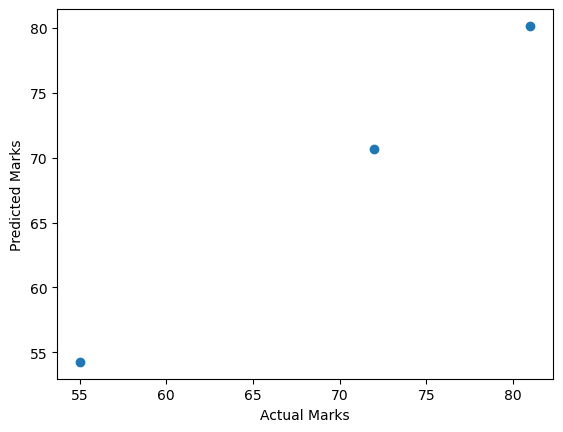

In [48]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")

plt.show()

In [49]:
new_student = [[6, 90, 80, 78]]

prediction = model.predict(new_student)

print(prediction)

[80.3073971]


C:\Users\Dictator\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
